In [1]:

import sys, math, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

warnings.filterwarnings("ignore")

# Resolve project root so the project modules import cleanly
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Project imports
from config.settings    import solver_variable_names, solver_flux_names
from config.initialize  import parameters, operating_inputs, init_x_for
from model.dualscale    import PEMFC
from model.kinetic_eq   import Rproton, eta_ccl, fdrop
from model.coefficients import n_cell

# Sweep grid used to pick experimental points to compare against
I_tested   = [10, 20, 30, 35, 40, 45, 50]      # A      current points
TFC_tested = [50, 60, 70]              # degC   cell temperature
PAC_tested = [1.3e5, 1.4e5, 1.5e5]     # Pa     anode/cathode pressure
RHC_tested = [0, 50]                   # %      cathode relative humidity

print("Imports OK.")


Imports OK.


In [2]:
# ---- Cell 2: Import experiment data ----
exp_file       = project_root / "data" / "Polar_curves.xlsx"
polardata_exp  = pd.read_excel(exp_file, sheet_name=None)

print(f"Loaded {len(polardata_exp)} conditions from {exp_file.name}")
for name, df in polardata_exp.items():
    i_min, i_max = df["I_LOAD"].min(), df["I_LOAD"].max()
    print(f"  {name:18s}  {len(df):3d} points,  I = {i_min:.1f}-{i_max:.1f} A")


Loaded 12 conditions from Polar_curves.xlsx
  T50_P300_HRC0         7 points,  I = 9.9-49.9 A
  T50_P300_HRC50        7 points,  I = 10.0-50.1 A
  T50_P400_HRC50        7 points,  I = 10.0-50.1 A
  T50_P500_HRC50        7 points,  I = 10.0-50.1 A
  T60_P300_HRC0         7 points,  I = 10.2-50.1 A
  T60_P300_HRC50        7 points,  I = 9.9-50.1 A
  T60_P400_HRC50        7 points,  I = 9.9-50.1 A
  T60_P500_HRC50        7 points,  I = 9.9-50.1 A
  T70_P300_HRC0         7 points,  I = 10.0-50.0 A
  T70_P300_HRC50        7 points,  I = 10.0-50.0 A
  T70_P400_HRC50        7 points,  I = 10.0-50.0 A
  T70_P500_HRC50        7 points,  I = 10.0-50.0 A


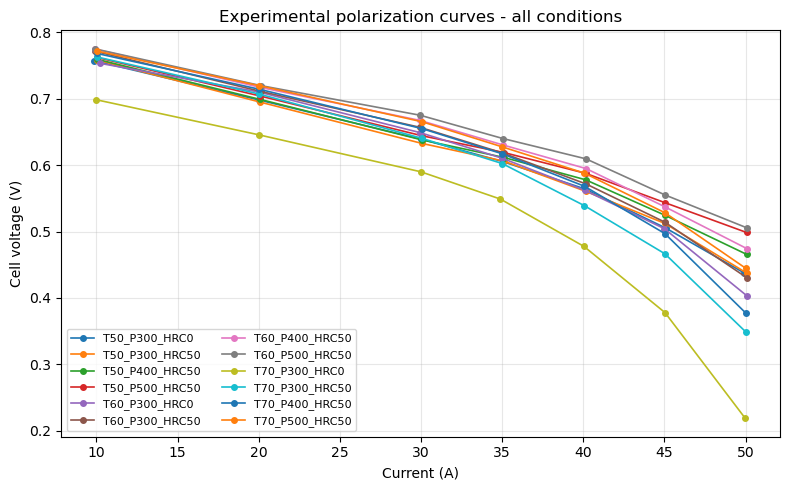

In [3]:
# ---- Cell 3: Plot the experimental data ----
fig, ax = plt.subplots(figsize=(8, 5))
for name, df in polardata_exp.items():
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    ax.plot(i_exp, v_exp, "o-", linewidth=1.2, markersize=4, label=name)

ax.set_xlabel("Current (A)")
ax.set_ylabel("Cell voltage (V)")
ax.set_title("Experimental polarization curves - all conditions")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best", ncol=2)
plt.tight_layout()
plt.show()


In [4]:
# ---- Cell 4: Setup the undetermined parameters ----
# Edit values in `manual_params` to fit the curves by hand, then re-run
# cells 5 / 6 to see the new fit.
manual_params = {
    "OCV":          0.84,    # V        open-circuit voltage
    "i0_c_ref":     1.1556,    # A/m^2    cathode exchange current density (ref)
    "kappa_c":     2.624,     # -        O2 reaction order (1 = first-order, literature-typical)
    "tau":          1.554,     # -        GDL tortuosity exponent
    "Re":           9.521e-06,  # Ohm.m^2  electronic resistance
    "epsilon_mc":   0.1836,   # -        ionomer fraction in micro CL
    "epsilon_gdl":  0.6,     # -        GDL porosity
    "epsilon_c":    0.223,   # -        cathode ionomer fraction
    "epsilon_cl":   0.1588,     # -        catalyst-layer porosity
    "a_slim":       0.02,    # -        saturation-switch slope
    "b_slim":       0.25,     # -        saturation-switch intercept
    "a_switch":     0.1,     # -        saturation-switch threshold
    "Hcl":          1.47e-5,   # m        catalyst-layer thickness
    "Hgdl":         2.85e-4,  # m        GDL thickness
}


def simulate_polar(cond_key, params_override, verbose=True):
    """Run the dual-scale model (without BoP) at every I in I_tested for
    one experimental condition. Returns (i_keep, Ucell_keep, internals) where
    internals is a dict with lists of C_O2_ccl, s_ccl, and fdrop at each point.
    """
    # Parse condition key
    T_des = int(cond_key.split("_")[0][1:])
    P_des = int(cond_key.split("_")[1][1:]) * 100 + 1e5
    RHC   = int(cond_key.split("_")[2][3:])

    # Local copies so we never mutate the global defaults
    p  = deepcopy(parameters);  p.update(params_override)
    p["aux_system"]  = False
    op = deepcopy(operating_inputs)
    op["Tfc"]       = T_des + 273.15
    op["Pa_des"]    = P_des
    op["Pc_des"]    = P_des
    op["Phi_c_des"] = RHC / 100

    model = PEMFC(param=p, operating_inputs=op,
                  variable_names=solver_variable_names,
                  flux_names=solver_flux_names)

    i_keep, Ucell_keep = [], []
    C_O2_ccl_keep, s_ccl_keep, fdrop_keep = [], [], []
    t_per_point = []
    for I_LOAD in I_tested:
        i_density = I_LOAD / p["Aact"]
        op["current_density"] = lambda t, _i=i_density: _i
        t0 = time.perf_counter()
        try:
            x0  = init_x_for("dual-scale", op, model.parameters)
            sol = solve_ivp(model.dxdt, (0, 30), x0,
                            method="BDF", max_step=2e-1)
            if not sol.success:
                if verbose:
                    print(f"    I = {I_LOAD:5.1f} A  ->  solver failed: {sol.message}")
                continue
            last = {k: sol.y[idx, -1] for idx, k in enumerate(model.variable_names)}
            Rmem, _, _ = Rproton(last, model.parameters, op)
            eta_c      = eta_ccl(last, op, model.parameters)
            Ucell      = p["OCV"] - i_density * (sum(Rmem) + p["Re"]) - eta_c
            if not (np.isfinite(Ucell) and 0.0 < Ucell < 1.3):
                if verbose:
                    print(f"    I = {I_LOAD:5.1f} A  ->  unphysical Ucell = {Ucell}")
                continue
            i_keep.append(I_LOAD)
            Ucell_keep.append(float(Ucell))
            C_O2_ccl_keep.append(float(last['C_O2_ccl']))
            s_ccl_keep.append(float(last['s_ccl']))
            fdrop_keep.append(float(fdrop(last, op, p)))
            t_per_point.append(time.perf_counter() - t0)
        except Exception as exc:
            if verbose:
                print(f"    I = {I_LOAD:5.1f} A  ->  exception: {type(exc).__name__}: {exc}")
            continue
    if verbose:
        avg = (sum(t_per_point) / len(t_per_point)) if t_per_point else 0.0
        print(f"  {cond_key}: {len(i_keep)}/{len(I_tested)} points OK   (avg {avg:.2f} s/point)")
    internals = {"C_O2_ccl": C_O2_ccl_keep, "s_ccl": s_ccl_keep, "fdrop": fdrop_keep}
    return i_keep, Ucell_keep, internals


print("Manual params dict ready.")
print("Tip: tweak values above, then re-run cells 5/6 -- you don't need to re-run cells 1-3.")

Manual params dict ready.
Tip: tweak values above, then re-run cells 5/6 -- you don't need to re-run cells 1-3.


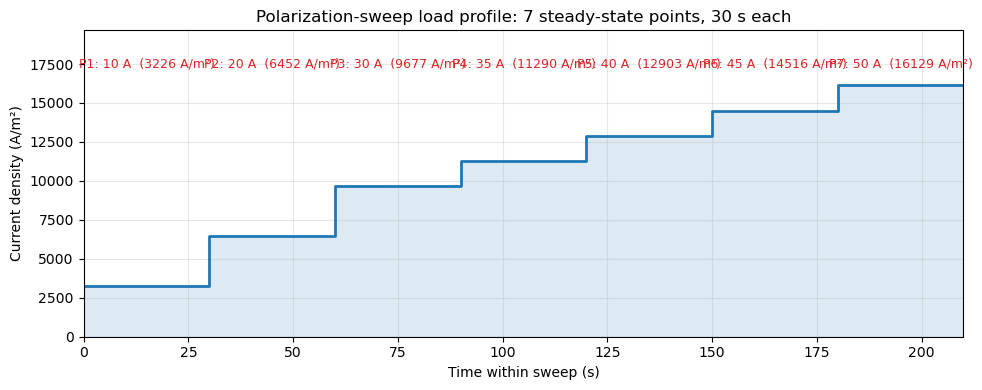

For each polar point we hold a constant load for 30 s:
  P1:  I =  10.0 A  ->  i =  3225.8 A/m²
  P2:  I =  20.0 A  ->  i =  6451.6 A/m²
  P3:  I =  30.0 A  ->  i =  9677.4 A/m²
  P4:  I =  35.0 A  ->  i = 11290.3 A/m²
  P5:  I =  40.0 A  ->  i = 12903.2 A/m²
  P6:  I =  45.0 A  ->  i = 14516.1 A/m²
  P7:  I =  50.0 A  ->  i = 16129.0 A/m²


In [5]:
t_hold = 30.0       # seconds per point -- must match the t_span used inside simulate_polar()
i_A_per_m2 = [I / parameters["Aact"] for I in I_tested]

# Build the staircase
t_stairs, i_stairs = [], []
t0 = 0.0
for i_density in i_A_per_m2:
    t_stairs += [t0, t0 + t_hold]
    i_stairs += [i_density, i_density]
    t0 += t_hold

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(t_stairs, i_stairs, where="post", linewidth=2, color="tab:blue")
ax.fill_between(t_stairs, 0, i_stairs, step="post", alpha=0.15, color="tab:blue")
y_top = max(i_stairs) * 1.06
for k, (I, i_d) in enumerate(zip(I_tested, i_A_per_m2)):
    t_mid = (k + 0.5) * t_hold
    label = "P" + str(k + 1) + ": " + str(I) + " A  (" + format(i_d, ".0f") + " A/m²)"
    ax.text(t_mid, y_top, label, ha="center", va="bottom", fontsize=9,
            color="tab:red", rotation=0)
ax.set_xlim(0, len(I_tested) * t_hold)
ax.set_ylim(0, y_top * 1.15)
ax.set_xlabel("Time within sweep (s)")
ax.set_ylabel("Current density (A/m²)")
ax.set_title("Polarization-sweep load profile: "
             + str(len(I_tested)) + " steady-state points, "
             + format(t_hold, "g") + " s each")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("For each polar point we hold a constant load for", format(t_hold, "g"), "s:")
for k, (I, i_d) in enumerate(zip(I_tested, i_A_per_m2), 1):
    print("  P" + str(k) + ":  I = " + format(I, "5.1f") + " A  ->  i = "
          + format(i_d, "7.1f") + " A/m²")

Simulating T60_P400_HRC50 ...
  T60_P400_HRC50: 7/7 points OK   (avg 3.24 s/point)


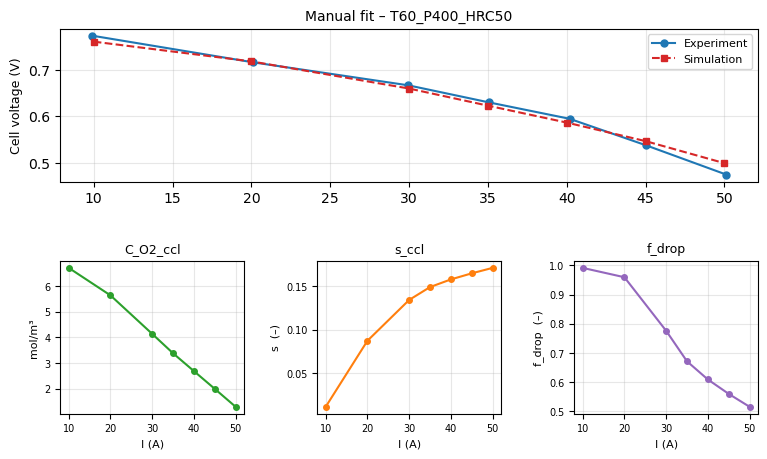

RMSE on 7 points: 12.1 mV


In [6]:

# ---- Cell 6: Plot one-condition fit ----
# Change CHOSEN_COND to any key printed by cell 2.
CHOSEN_COND = "T60_P400_HRC50"
print(f"Simulating {CHOSEN_COND} ...")

# Experimental
df    = polardata_exp[CHOSEN_COND]
i_exp = df["I_LOAD"].to_numpy(dtype=float)
v_exp = df["VFC"].to_numpy(dtype=float) / n_cell

# Simulation with current manual_params
i_sim, v_sim, internals = simulate_polar(CHOSEN_COND, manual_params)

# --- Figure: polar curve (top, full-width) + 3 diagnostics (bottom row) ---
fig = plt.figure(figsize=(9, 5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.40)
ax_polar = fig.add_subplot(gs[0, :])
ax_co2   = fig.add_subplot(gs[1, 0])
ax_s     = fig.add_subplot(gs[1, 1])
ax_fd    = fig.add_subplot(gs[1, 2])

# Polarization curve
ax_polar.plot(i_exp, v_exp, "o-",  color="tab:blue", markersize=5, label="Experiment")
if i_sim:
    ax_polar.plot(i_sim, v_sim, "s--", color="tab:red",  markersize=5, label="Simulation")
ax_polar.set_ylabel("Cell voltage (V)", fontsize=9)
ax_polar.set_title(f"Manual fit – {CHOSEN_COND}", fontsize=10)
ax_polar.grid(True, alpha=0.3)
ax_polar.legend(loc="best", fontsize=8)

# Diagnostic subplots (simulation points only)
if i_sim:
    ax_co2.plot(i_sim, internals["C_O2_ccl"], "o-", color="tab:green",  markersize=4)
    ax_co2.set_ylabel("mol/m³", fontsize=8)
    ax_co2.set_xlabel("I (A)", fontsize=8)
    ax_co2.set_title("C_O2_ccl", fontsize=9)
    ax_co2.grid(True, alpha=0.3)
    ax_co2.tick_params(labelsize=7)

    ax_s.plot(i_sim, internals["s_ccl"], "o-", color="tab:orange", markersize=4)
    ax_s.set_ylabel("s  (–)", fontsize=8)
    ax_s.set_xlabel("I (A)", fontsize=8)
    ax_s.set_title("s_ccl", fontsize=9)
    ax_s.grid(True, alpha=0.3)
    ax_s.tick_params(labelsize=7)

    ax_fd.plot(i_sim, internals["fdrop"], "o-", color="tab:purple", markersize=4)
    ax_fd.set_ylabel("f_drop  (–)", fontsize=8)
    ax_fd.set_xlabel("I (A)", fontsize=8)
    ax_fd.set_title("f_drop", fontsize=9)
    ax_fd.grid(True, alpha=0.3)
    ax_fd.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

# RMSE on the simulation points only
if i_sim:
    idx_match = [int(np.argmin((i_t - i_exp) ** 2)) for i_t in i_sim]
    rmse = float(np.sqrt(np.mean((np.array(v_sim) - v_exp[idx_match]) ** 2)))
    print(f"RMSE on {len(i_sim)} points: {rmse * 1000:.1f} mV")
else:
    print("No simulation points succeeded -- check the parameters in cell 4.")


Simulating T60_P400_HRC50 ...
  T60_P400_HRC50: 7/7 points OK   (avg 3.25 s/point)
Simulating T60_P500_HRC50 ...
  T60_P500_HRC50: 7/7 points OK   (avg 3.44 s/point)


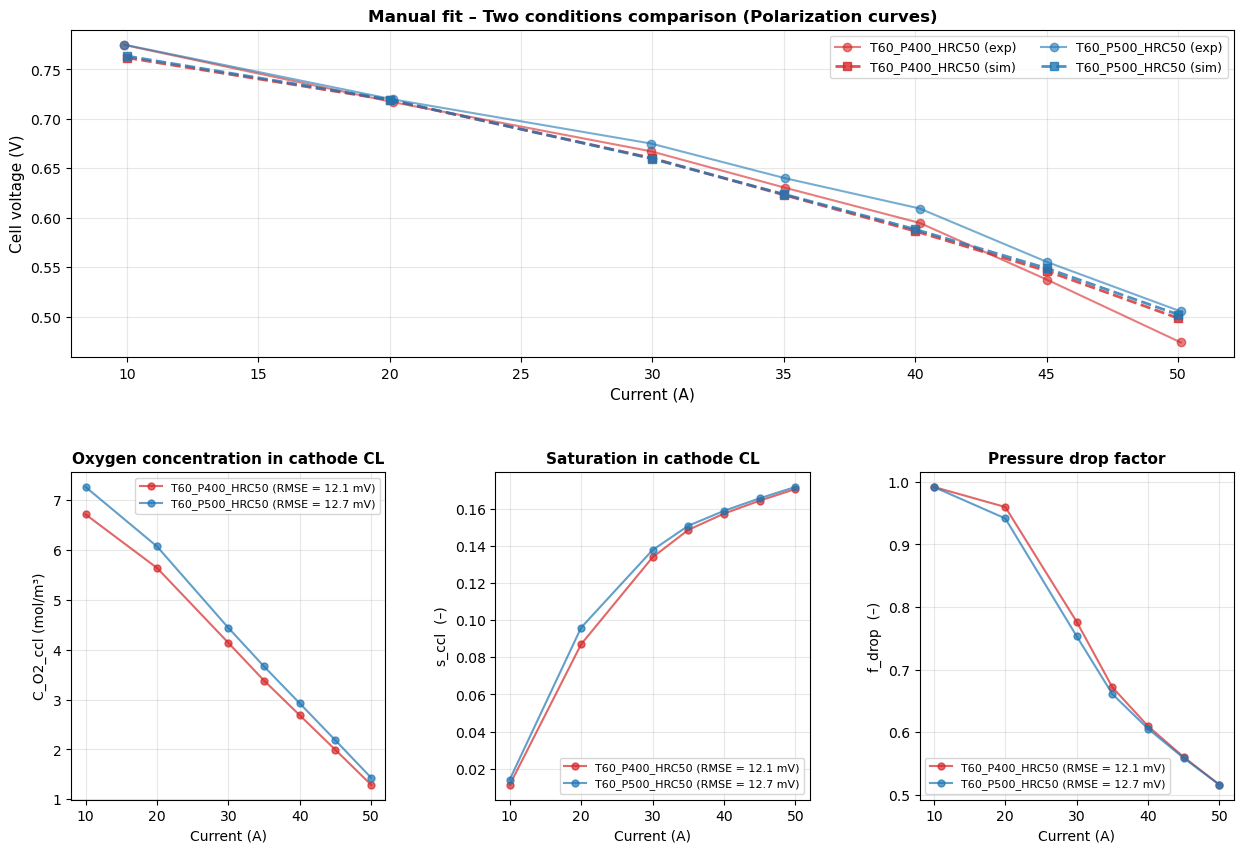

In [7]:
# ---- Cell 7: Plot two-condition fit with internal states overlaid ----
CHOSEN_2 = ["T60_P400_HRC50", "T60_P500_HRC50"]

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)
ax_polar = fig.add_subplot(gs[0, :])
ax_co2   = fig.add_subplot(gs[1, 0])
ax_s     = fig.add_subplot(gs[1, 1])
ax_fd    = fig.add_subplot(gs[1, 2])

# Storage for all data
all_results = {}
colors = {"T60_P400_HRC50": "tab:red", "T60_P500_HRC50": "tab:blue"}

# Simulate both conditions
for cond_key in CHOSEN_2:
    print(f"Simulating {cond_key} ...")
    df    = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    i_sim, v_sim, internals = simulate_polar(cond_key, manual_params)
    
    all_results[cond_key] = {"i_exp": i_exp, "v_exp": v_exp, "i_sim": i_sim, "v_sim": v_sim, "internals": internals}
    
    # Plot polarization curves on shared plot
    ax_polar.plot(i_exp, v_exp, "o-", color=colors[cond_key], markersize=6, label=f"{cond_key} (exp)", alpha=0.6, linewidth=1.5)
    if i_sim:
        ax_polar.plot(i_sim, v_sim, "s--", color=colors[cond_key], markersize=6, label=f"{cond_key} (sim)", alpha=0.8, linewidth=2)

ax_polar.set_ylabel("Cell voltage (V)", fontsize=11)
ax_polar.set_xlabel("Current (A)", fontsize=11)
ax_polar.set_title("Manual fit – Two conditions comparison (Polarization curves)", fontsize=12, fontweight="bold")
ax_polar.grid(True, alpha=0.3)
ax_polar.legend(loc="best", fontsize=9, ncol=2)

# Plot internal states for both conditions overlaid
for cond_key, color in colors.items():
    i_sim = all_results[cond_key]["i_sim"]
    internals = all_results[cond_key]["internals"]
    v_exp = all_results[cond_key]["v_exp"]
    v_sim = all_results[cond_key]["v_sim"]
    
    if i_sim:
        idx_match = [int(np.argmin((i_t - all_results[cond_key]["i_exp"]) ** 2)) for i_t in i_sim]
        rmse = float(np.sqrt(np.mean((np.array(v_sim) - v_exp[idx_match]) ** 2)))
        rmse_str = f"RMSE = {rmse*1000:.1f} mV"
        label = f"{cond_key} ({rmse_str})"
        
        ax_co2.plot(i_sim, internals["C_O2_ccl"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)
        ax_s.plot(i_sim, internals["s_ccl"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)
        ax_fd.plot(i_sim, internals["fdrop"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)

# Format diagnostic plots
ax_co2.set_ylabel("C_O2_ccl (mol/m³)", fontsize=10)
ax_co2.set_xlabel("Current (A)", fontsize=10)
ax_co2.set_title("Oxygen concentration in cathode CL", fontsize=11, fontweight="bold")
ax_co2.grid(True, alpha=0.3)
ax_co2.legend(fontsize=8, loc="best")

ax_s.set_ylabel("s_ccl  (–)", fontsize=10)
ax_s.set_xlabel("Current (A)", fontsize=10)
ax_s.set_title("Saturation in cathode CL", fontsize=11, fontweight="bold")
ax_s.grid(True, alpha=0.3)
ax_s.legend(fontsize=8, loc="best")

ax_fd.set_ylabel("f_drop  (–)", fontsize=10)
ax_fd.set_xlabel("Current (A)", fontsize=10)
ax_fd.set_title("Pressure drop factor", fontsize=11, fontweight="bold")
ax_fd.grid(True, alpha=0.3)
ax_fd.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

Simulating T60_P300_HRC50 ...
  T60_P300_HRC50: 7/7 points OK   (avg 3.28 s/point)
Simulating T60_P400_HRC50 ...
  T60_P400_HRC50: 7/7 points OK   (avg 3.26 s/point)
Simulating T60_P500_HRC50 ...
  T60_P500_HRC50: 7/7 points OK   (avg 3.47 s/point)
Simulating T50_P400_HRC50 ...
    I =  50.0 A  ->  solver failed: Required step size is less than spacing between numbers.
  T50_P400_HRC50: 6/7 points OK   (avg 3.23 s/point)
Simulating T70_P400_HRC50 ...
  T70_P400_HRC50: 7/7 points OK   (avg 2.29 s/point)


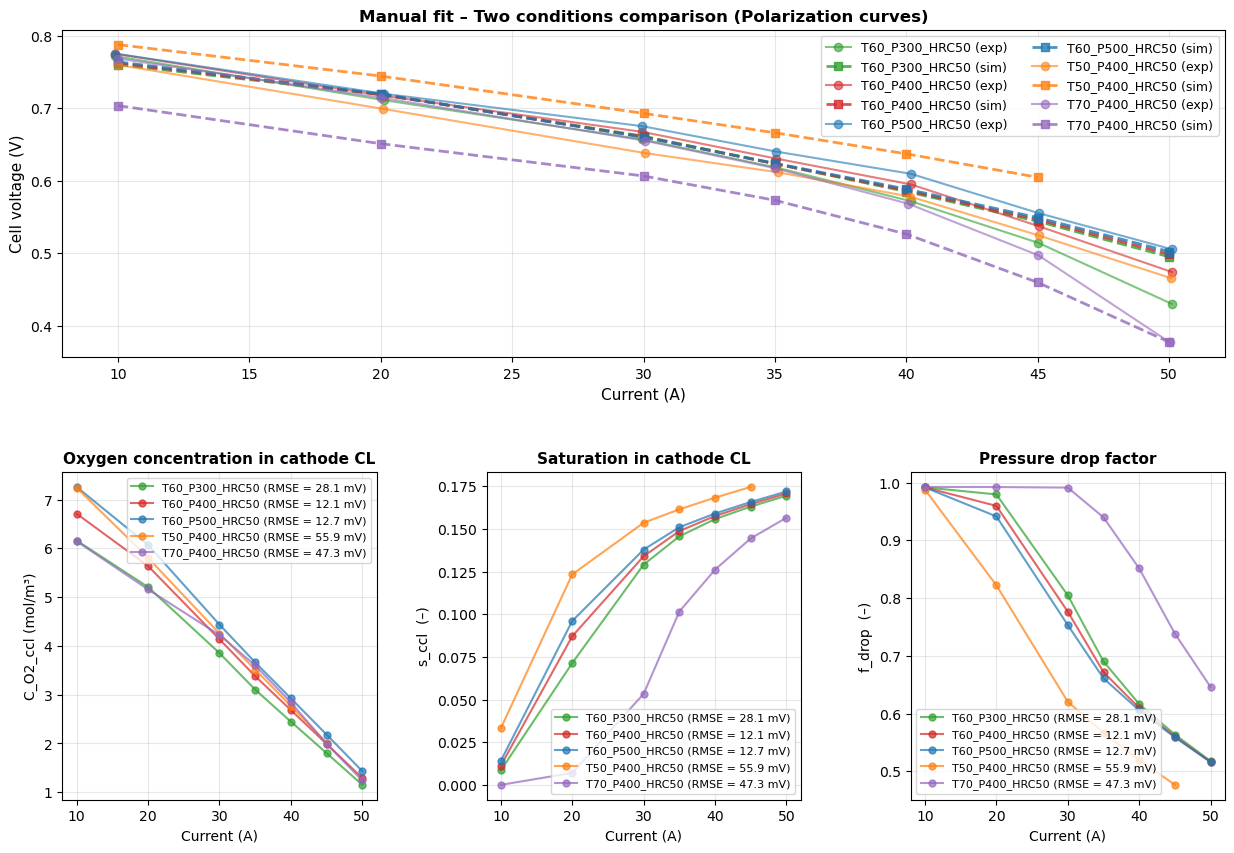

In [8]:
# ---- Cell 7: Plot two-condition fit with internal states overlaid ----
CHOSEN_2 = ["T60_P300_HRC50","T60_P400_HRC50", "T60_P500_HRC50",
                        "T50_P400_HRC50", "T70_P400_HRC50"]

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)
ax_polar = fig.add_subplot(gs[0, :])
ax_co2   = fig.add_subplot(gs[1, 0])
ax_s     = fig.add_subplot(gs[1, 1])
ax_fd    = fig.add_subplot(gs[1, 2])

# Storage for all data
all_results = {}
colors = {"T60_P300_HRC50": "tab:green", "T60_P400_HRC50": "tab:red", "T60_P500_HRC50": "tab:blue",
          "T50_P400_HRC50": "tab:orange", "T70_P400_HRC50": "tab:purple"}

# Simulate both conditions
for cond_key in CHOSEN_2:
    print(f"Simulating {cond_key} ...")
    df    = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    i_sim, v_sim, internals = simulate_polar(cond_key, manual_params)
    
    all_results[cond_key] = {"i_exp": i_exp, "v_exp": v_exp, "i_sim": i_sim, "v_sim": v_sim, "internals": internals}
    
    # Plot polarization curves on shared plot
    ax_polar.plot(i_exp, v_exp, "o-", color=colors[cond_key], markersize=6, label=f"{cond_key} (exp)", alpha=0.6, linewidth=1.5)
    if i_sim:
        ax_polar.plot(i_sim, v_sim, "s--", color=colors[cond_key], markersize=6, label=f"{cond_key} (sim)", alpha=0.8, linewidth=2)

ax_polar.set_ylabel("Cell voltage (V)", fontsize=11)
ax_polar.set_xlabel("Current (A)", fontsize=11)
ax_polar.set_title("Manual fit – Two conditions comparison (Polarization curves)", fontsize=12, fontweight="bold")
ax_polar.grid(True, alpha=0.3)
ax_polar.legend(loc="best", fontsize=9, ncol=2)

# Plot internal states for both conditions overlaid
for cond_key, color in colors.items():
    i_sim = all_results[cond_key]["i_sim"]
    internals = all_results[cond_key]["internals"]
    v_exp = all_results[cond_key]["v_exp"]
    v_sim = all_results[cond_key]["v_sim"]
    
    if i_sim:
        idx_match = [int(np.argmin((i_t - all_results[cond_key]["i_exp"]) ** 2)) for i_t in i_sim]
        rmse = float(np.sqrt(np.mean((np.array(v_sim) - v_exp[idx_match]) ** 2)))
        rmse_str = f"RMSE = {rmse*1000:.1f} mV"
        label = f"{cond_key} ({rmse_str})"
        
        ax_co2.plot(i_sim, internals["C_O2_ccl"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)
        ax_s.plot(i_sim, internals["s_ccl"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)
        ax_fd.plot(i_sim, internals["fdrop"], "o-", color=color, markersize=5, label=label, linewidth=1.5, alpha=0.7)

# Format diagnostic plots
ax_co2.set_ylabel("C_O2_ccl (mol/m³)", fontsize=10)
ax_co2.set_xlabel("Current (A)", fontsize=10)
ax_co2.set_title("Oxygen concentration in cathode CL", fontsize=11, fontweight="bold")
ax_co2.grid(True, alpha=0.3)
ax_co2.legend(fontsize=8, loc="best")

ax_s.set_ylabel("s_ccl  (–)", fontsize=10)
ax_s.set_xlabel("Current (A)", fontsize=10)
ax_s.set_title("Saturation in cathode CL", fontsize=11, fontweight="bold")
ax_s.grid(True, alpha=0.3)
ax_s.legend(fontsize=8, loc="best")

ax_fd.set_ylabel("f_drop  (–)", fontsize=10)
ax_fd.set_xlabel("Current (A)", fontsize=10)
ax_fd.set_title("Pressure drop factor", fontsize=11, fontweight="bold")
ax_fd.grid(True, alpha=0.3)
ax_fd.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()